In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [6]:
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (913000, 4)


In [7]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["date"] = pd.to_datetime(df["date"])

print("Date converted successfully!")
print(df.dtypes)

Date converted successfully!
date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object


In [12]:
df["sales"].describe()

,sales
count,913000.000000
mean,52.250287
std,28.801144
min,0.000000
25%,30.000000
50%,47.000000
75%,70.000000
max,231.000000


In [16]:
print(sales_stats.to_string(index=False))

Statistic         Value
    count 913000.000000
     mean     52.250287
      std     28.801144
      min      0.000000
      25%     30.000000
      50%     47.000000
      75%     70.000000
      max    231.000000


In [18]:
from IPython.display import HTML, display

html = """
<style>
.sales-table {
    border-collapse: collapse;
    width: 75%;
    margin: 20px auto;
    font-family: Arial, sans-serif;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
}

.sales-table th {
    background-color: #1565C0;
    color: white;
    padding: 14px;
    font-size: 17px;
    text-align: center;
}

.sales-table td {
    padding: 12px;
    text-align: center;
    color: #222222;
    font-size: 16px;
    font-weight: 500;
}

.sales-table tr:nth-child(even) {
    background-color: #E3F2FD;
}

.sales-table tr:nth-child(odd) {
    background-color: white;
}

.sales-table tr:hover {
    background-color: #BBDEFB;
}
</style>

<table class="sales-table">
    <tr>
        <th>📊 Statistic</th>
        <th>Value</th>
    </tr>
    <tr>
        <td>📌 Count</td>
        <td><b>913,000</b></td>
    </tr>
    <tr>
        <td>📈 Mean</td>
        <td><b>52.25</b></td>
    </tr>
    <tr>
        <td>📊 Standard Deviation</td>
        <td><b>28.80</b></td>
    </tr>
    <tr>
        <td>⬇️ Minimum</td>
        <td><b>0</b></td>
    </tr>
    <tr>
        <td>25%</td>
        <td><b>30</b></td>
    </tr>
    <tr>
        <td>50% (Median)</td>
        <td><b>47</b></td>
    </tr>
    <tr>
        <td>75%</td>
        <td><b>70</b></td>
    </tr>
    <tr>
        <td>⬆️ Maximum</td>
        <td><b>231</b></td>
    </tr>
</table>
"""

display(HTML(html))

📊 Statistic,Value
📌 Count,"913,000"
📈 Mean,52.25
📊 Standard Deviation,28.80
⬇️ Minimum,0
25%,30
50% (Median),47
75%,70
⬆️ Maximum,231


/tmp/ipykernel_928/1087609651.py:16: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


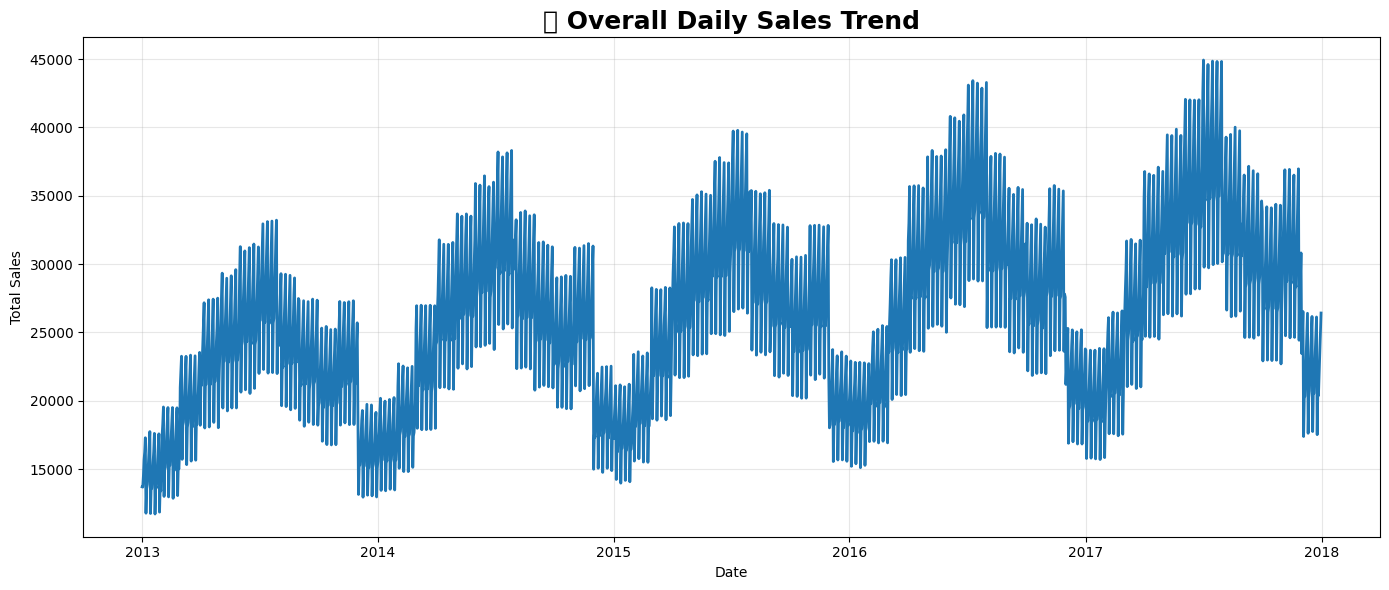

In [19]:
daily_sales = df.groupby("date")["sales"].sum()

plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    linewidth=2
)

plt.title("📈 Overall Daily Sales Trend", fontsize=18, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
store_sales = df.groupby("store")["sales"].sum().sort_values(ascending=False)

print("🏪 TOTAL SALES BY STORE")
print(store_sales)

🏪 TOTAL SALES BY STORE
store
2     6120128
8     5856169
3     5435144
10    5360158
9     5025976
4     5012639
1     4315603
5     3631016
6     3627670
7     3320009
Name: sales, dtype: int64


/tmp/ipykernel_928/1406770317.py:24: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


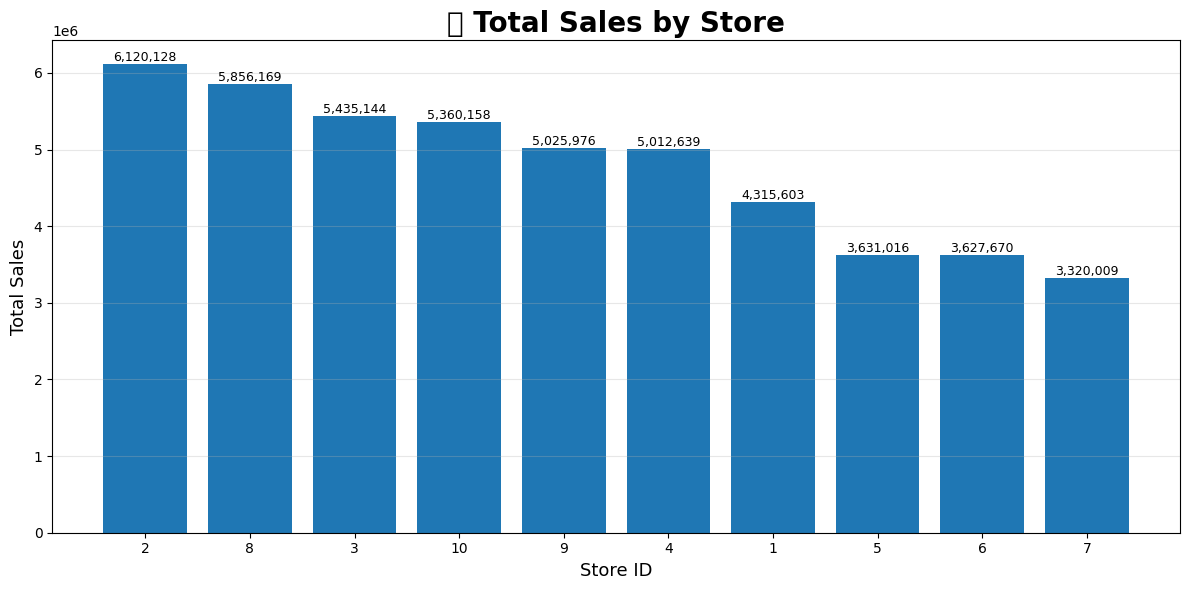

In [21]:
plt.figure(figsize=(12, 6))

bars = plt.bar(
    store_sales.index.astype(str),
    store_sales.values
)

plt.title("🏪 Total Sales by Store", fontsize=20, fontweight="bold")
plt.xlabel("Store ID", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)

# Add values on top of bars
for bar, value in zip(bars, store_sales.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
item_sales = (
    df.groupby("item")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print("📦 TOTAL SALES BY ITEM")
print(item_sales)

📦 TOTAL SALES BY ITEM
item
15    1607442
28    1604713
13    1539621
18    1538876
25    1473334
45    1471467
38    1470330
22    1469971
36    1406548
8     1405108
10    1337133
11    1271925
12    1271534
29    1271240
33    1270183
24    1205975
50    1203009
35    1201541
14    1071531
31    1070845
46    1070764
2     1069564
7     1068777
6     1068281
9      938379
48     937703
43     936635
26     869981
20     867641
32     803107
39     801311
19     736892
30     736554
21     736190
42     669925
3      669087
17     602486
44     536811
49     535663
23     534979
37     534258
40     534094
34     469935
16     468480
27     402628
4      401907
47     401781
41     401759
1      401384
5      335230
Name: sales, dtype: int64


/tmp/ipykernel_928/3514554772.py:30: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


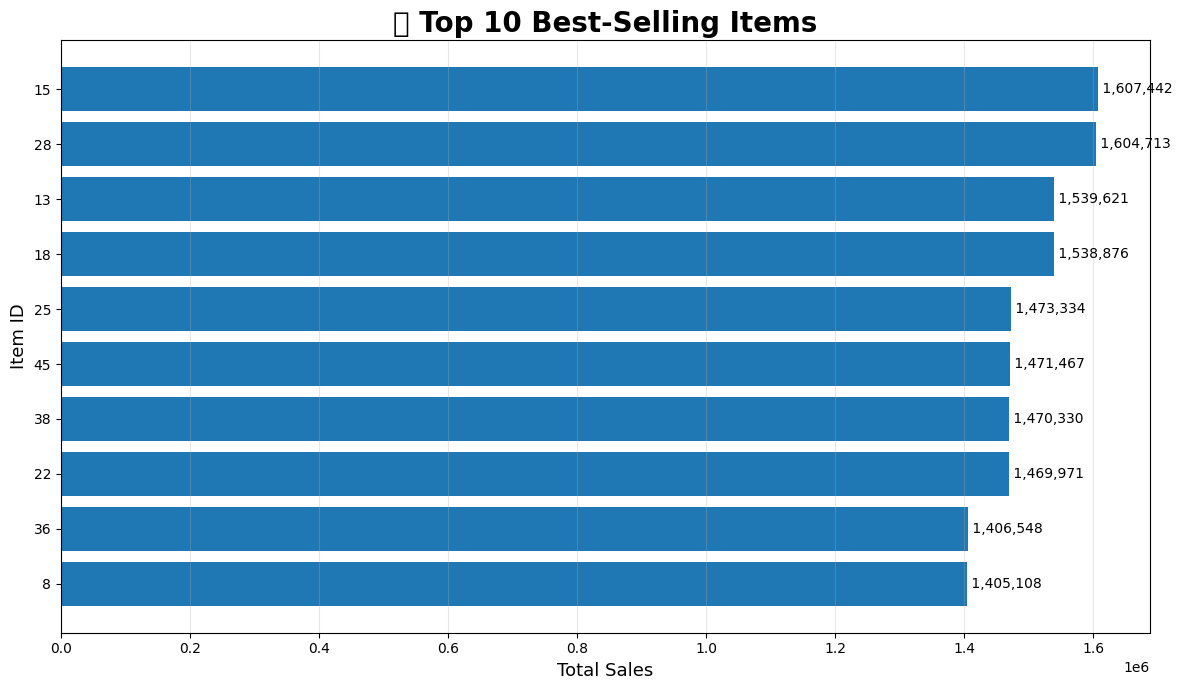

In [23]:
top_10_items = item_sales.head(10).sort_values()

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_10_items.index.astype(str),
    top_10_items.values
)

plt.title(
    "📦 Top 10 Best-Selling Items",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Total Sales", fontsize=13)
plt.ylabel("Item ID", fontsize=13)

# Display sales values
for bar, value in zip(bars, top_10_items.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:,.0f}",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# 📅 Monthly Sales Analysis

df["month"] = df["date"].dt.to_period("M")

monthly_sales = (
    df.groupby("month")["sales"]
    .sum()
)

print("📅 MONTHLY SALES")
print(monthly_sales)

📅 MONTHLY SALES
month
2013-01     454904
2013-02     459417
2013-03     617382
2013-04     682274
2013-05     763242
2013-06     795597
2013-07     855922
2013-08     766761
2013-09     689907
2013-10     656587
2013-11     692643
2013-12     506607
2014-01     525987
2014-02     529117
2014-03     704301
2014-04     788914
2014-05     882877
2014-06     906842
2014-07     989010
2014-08     885596
2014-09     785124
2014-10     758883
2014-11     800783
2014-12     578048
2015-01     552513
2015-02     551317
2015-03     730951
2015-04     824467
2015-05     926902
2015-06     937184
2015-07    1037350
2015-08     920401
2015-09     823332
2015-10     797253
2015-11     827645
2015-12     607572
2016-01     602439
2016-02     614957
2016-03     790881
2016-04     901950
2016-05     988730
2016-06    1022664
2016-07    1138718
2016-08     981494
2016-09     896831
2016-10     863637
2016-11     891448
2016-12     663411
2017-01     617306
2017-02     621369
2017-03     822667
2017-04  

/tmp/ipykernel_928/1473571709.py:28: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


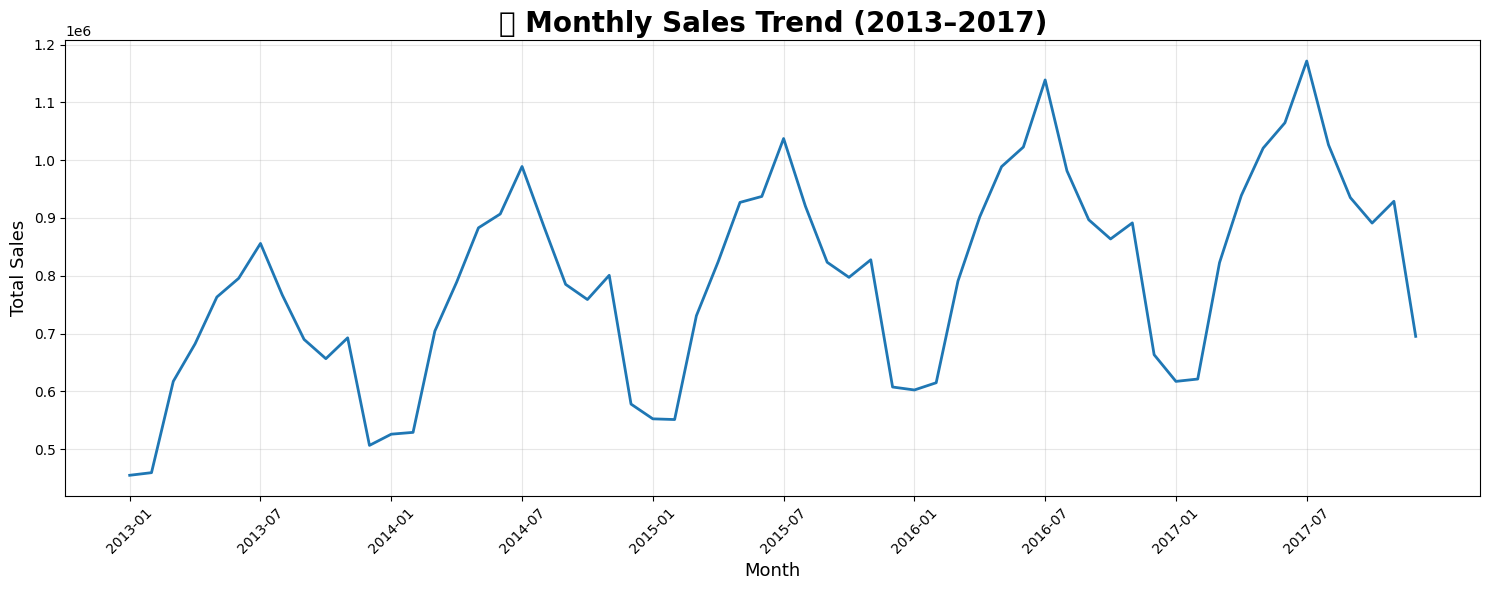

In [25]:
# 📅 Monthly Sales Trend

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    linewidth=2
)

plt.title(
    "📅 Monthly Sales Trend (2013–2017)",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)

# Show fewer x-axis labels so they don't overlap
plt.xticks(
    range(0, len(monthly_sales), 6),
    monthly_sales.index.astype(str)[::6],
    rotation=45
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# 🛠️ Feature Engineering

df["year"] = df["date"].dt.year
df["month_num"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

print("✅ Features created successfully!")

display(
    df[["date", "year", "month_num", "day", "day_of_week", "store", "item", "sales"]]
    .head(10)
)

✅ Features created successfully!


,date,year,month_num,day,day_of_week,store,item,sales
0,2013-01-01,2013,1,1,1,1,1,13
1,2013-01-02,2013,1,2,2,1,1,11
2,2013-01-03,2013,1,3,3,1,1,14
3,2013-01-04,2013,1,4,4,1,1,13
4,2013-01-05,2013,1,5,5,1,1,10
5,2013-01-06,2013,1,6,6,1,1,12
6,2013-01-07,2013,1,7,0,1,1,10
7,2013-01-08,2013,1,8,1,1,1,9
8,2013-01-09,2013,1,9,2,1,1,12
9,2013-01-10,2013,1,10,3,1,1,9


In [27]:
# 🤖 Prepare Features (X) and Target (y)

features = [
    "year",
    "month_num",
    "day",
    "day_of_week",
    "store",
    "item"
]

X = df[features]
y = df["sales"]

print("✅ Features (X):", X.shape)
print("🎯 Target (y):", y.shape)

print("\n📌 Features used:")
print(features)

print("\n🔍 First 5 rows of X:")
display(X.head())

print("\n🎯 First 5 values of y:")
display(y.head())

✅ Features (X): (913000, 6)
🎯 Target (y): (913000,)

📌 Features used:
['year', 'month_num', 'day', 'day_of_week', 'store', 'item']

🔍 First 5 rows of X:


,year,month_num,day,day_of_week,store,item
0,2013,1,1,1,1,1
1,2013,1,2,2,1,1
2,2013,1,3,3,1,1
3,2013,1,4,4,1,1
4,2013,1,5,5,1,1



🎯 First 5 values of y:


,sales
0,13
1,11
2,14
3,13
4,10


In [28]:
from IPython.display import HTML, display

# Create a small preview
preview = df[
    ["date", "year", "month_num", "day", "day_of_week", "store", "item", "sales"]
].head(8)

html = """
<style>
.feature-table {
    border-collapse: collapse;
    width: 95%;
    margin: 15px auto;
    font-family: Arial, sans-serif;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
}

.feature-table th {
    background-color: #1565C0;
    color: white;
    padding: 12px;
    text-align: center;
    font-size: 15px;
}

.feature-table td {
    padding: 10px;
    text-align: center;
    color: #222222;
    font-size: 14px;
    border-bottom: 1px solid #ddd;
}

.feature-table tr:nth-child(even) {
    background-color: #E3F2FD;
}

.feature-table tr:nth-child(odd) {
    background-color: #FFFFFF;
}

.feature-table tr:hover {
    background-color: #BBDEFB;
}
</style>

<div style="
    background: linear-gradient(135deg,#1565C0,#42A5F5);
    color:white;
    padding:15px;
    border-radius:12px;
    text-align:center;
    font-size:22px;
    font-weight:bold;
    margin-bottom:15px;">
    🛠️ FEATURE ENGINEERING — DATA PREVIEW
</div>
"""

# Convert DataFrame to HTML
html += preview.to_html(index=False, classes="feature-table")

display(HTML(html))

date,year,month_num,day,day_of_week,store,item,sales
2013-01-01,2013,1,1,1,1,1,13
2013-01-02,2013,1,2,2,1,1,11
2013-01-03,2013,1,3,3,1,1,14
2013-01-04,2013,1,4,4,1,1,13
2013-01-05,2013,1,5,5,1,1,10
2013-01-06,2013,1,6,6,1,1,12
2013-01-07,2013,1,7,0,1,1,10
2013-01-08,2013,1,8,1,1,1,9


In [29]:
display(HTML("""
<div style="
    background: linear-gradient(135deg,#6A1B9A,#AB47BC);
    color:white;
    padding:15px;
    border-radius:12px;
    text-align:center;
    font-size:22px;
    font-weight:bold;">
    🤖 MACHINE LEARNING DATA PREPARATION
</div>

<table style="width:80%; margin:20px auto; border-collapse:collapse; text-align:center;">
<tr style="background:#6A1B9A; color:white;">
    <th style="padding:12px;">Component</th>
    <th style="padding:12px;">Meaning</th>
    <th style="padding:12px;">Shape</th>
</tr>

<tr style="background:#F3E5F5; color:#222;">
    <td style="padding:12px;"><b>🧠 X</b></td>
    <td style="padding:12px;">Input Features</td>
    <td style="padding:12px;"><b>913,000 × 6</b></td>
</tr>

<tr style="background:#FFFFFF; color:#222;">
    <td style="padding:12px;"><b>🎯 y</b></td>
    <td style="padding:12px;">Target — Sales</td>
    <td style="padding:12px;"><b>913,000</b></td>
</tr>
</table>
"""))

Component,Meaning,Shape
🧠 X,Input Features,"913,000 × 6"
🎯 y,Target — Sales,"913,000"


In [31]:
# ⏳ Time-Based Train / Validation Split

train = df[df["date"] < "2017-01-01"].copy()
validation = df[df["date"] >= "2017-01-01"].copy()

X_train = train[features]
y_train = train["sales"]

X_validation = validation[features]
y_validation = validation["sales"]

print("✅ Time-based split completed!\n")

print("🟢 Training data:", X_train.shape)
print("🔵 Validation data:", X_validation.shape)

print("\n📅 Training period:")
print(train["date"].min(), "to", train["date"].max())

print("\n📅 Validation period:")
print(validation["date"].min(), "to", validation["date"].max())

✅ Time-based split completed!

🟢 Training data: (730500, 6)
🔵 Validation data: (182500, 6)

📅 Training period:
2013-01-01 00:00:00 to 2016-12-31 00:00:00

📅 Validation period:
2017-01-01 00:00:00 to 2017-12-31 00:00:00


In [32]:
from sklearn.ensemble import RandomForestRegressor

print("🤖 Training Random Forest Model...")

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("✅ Model training completed!")

🤖 Training Random Forest Model...
✅ Model training completed!


/tmp/ipykernel_928/3805453908.py:21: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


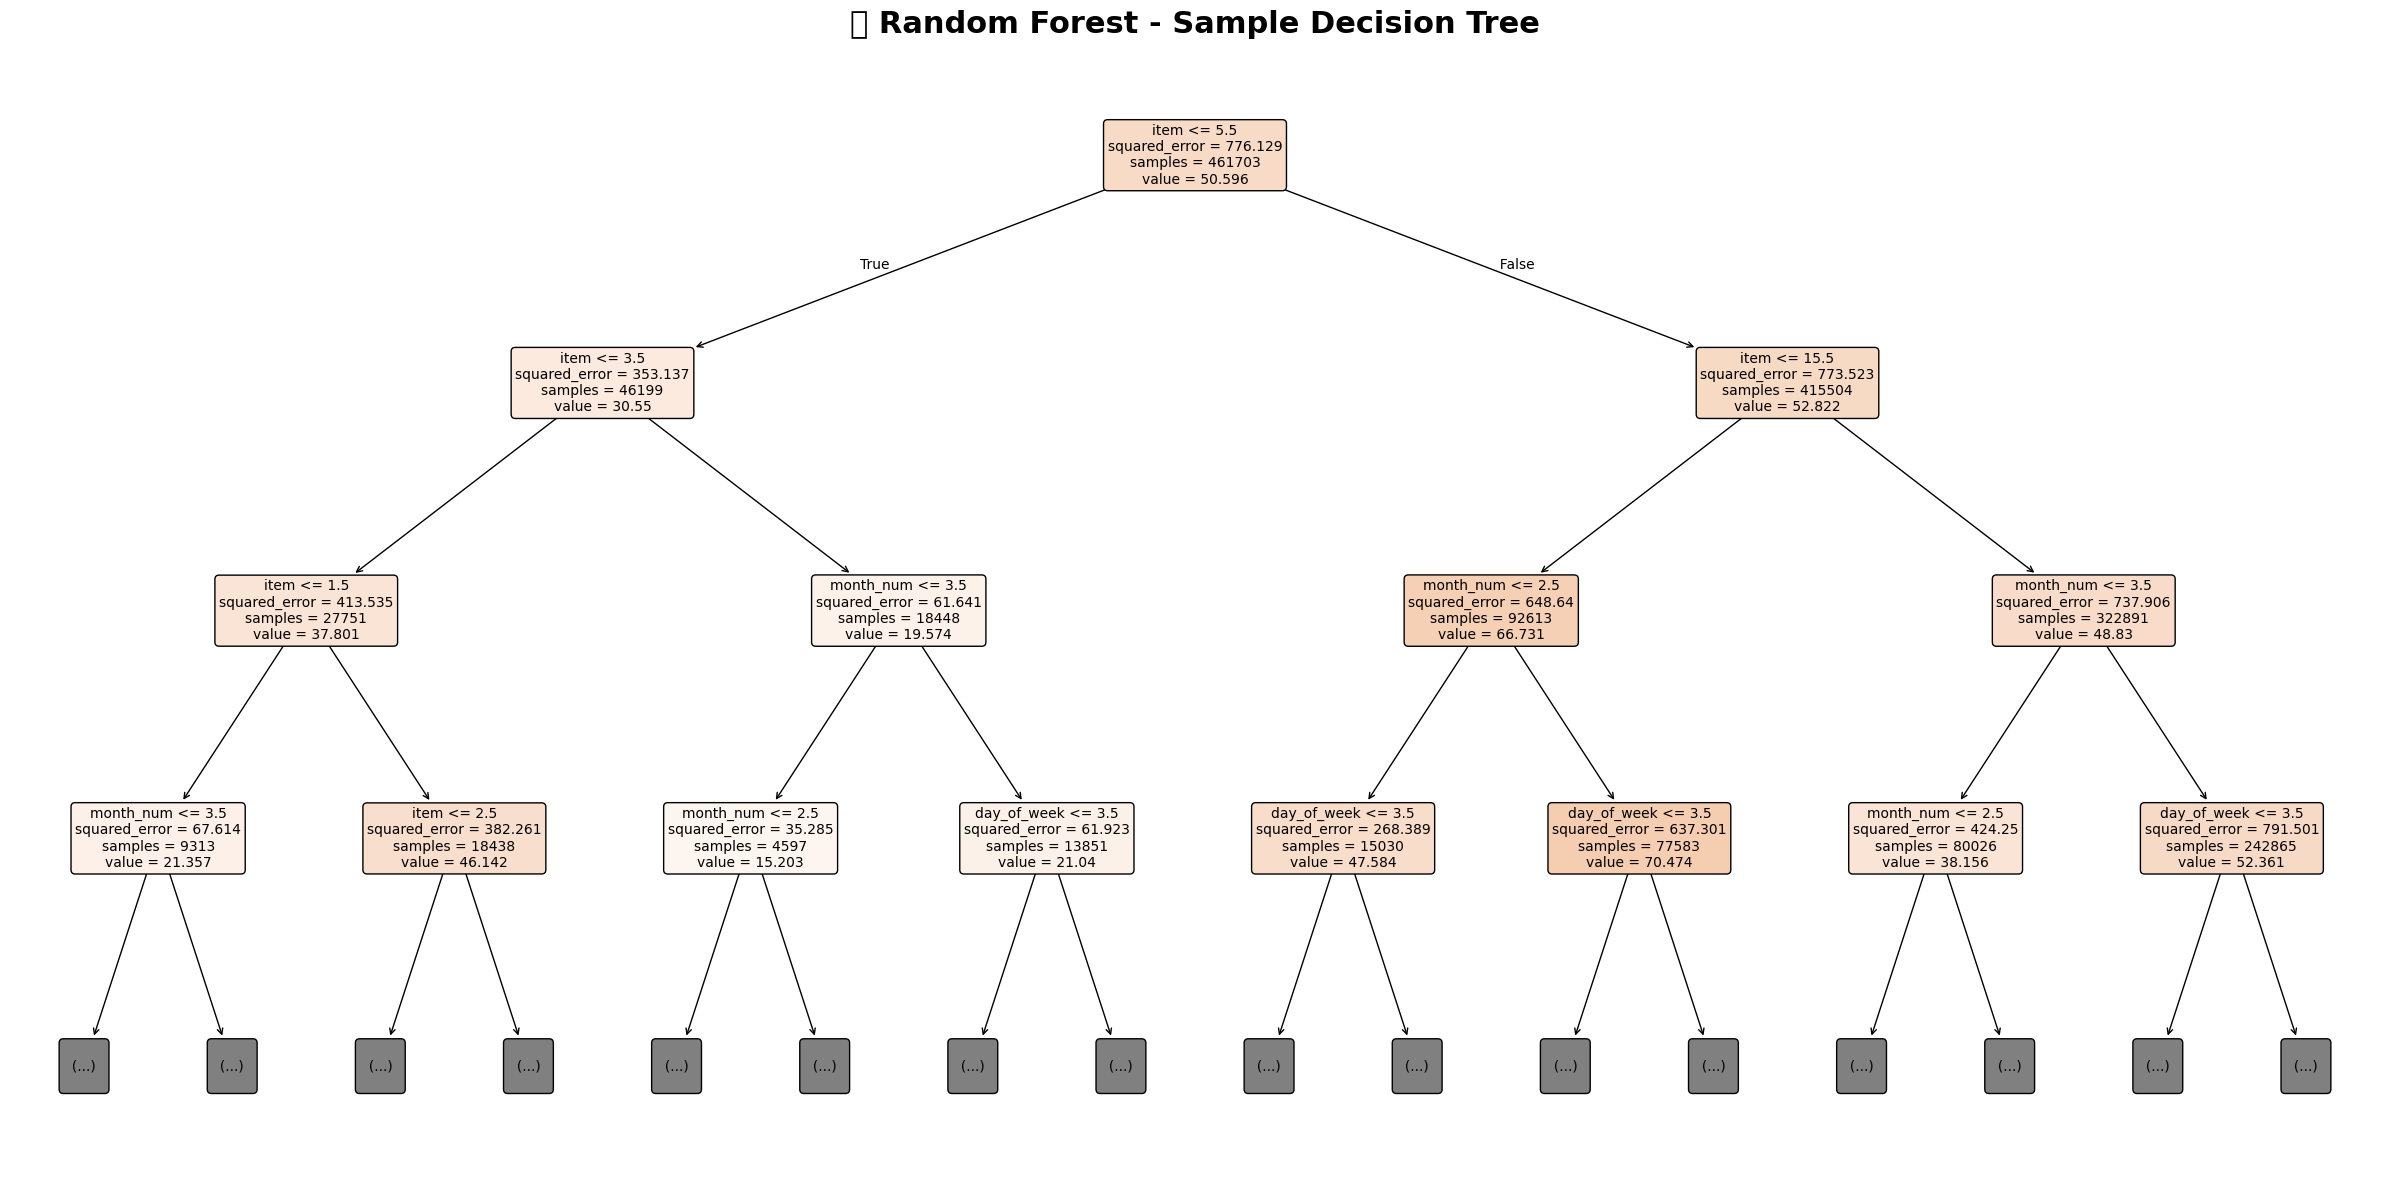

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))

plot_tree(
    model.estimators_[0],
    feature_names=features,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.title(
    "🌳 Random Forest - Sample Decision Tree",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [34]:
# 🔮 Generate Predictions

print("🔮 Generating predictions...")

y_pred = model.predict(X_validation)

print("✅ Predictions generated successfully!")

print("\n🎯 Actual Sales:")
print(y_validation.head(10).values)

print("\n🤖 Predicted Sales:")
print(y_pred[:10])

🔮 Generating predictions...
✅ Predictions generated successfully!

🎯 Actual Sales:
[19 15 10 16 14 24 14 20 18 11]

🤖 Predicted Sales:
[17.00076804 12.60246002 13.90889851 12.55149019 13.52604081 13.99766409
 14.78904818 17.58620866 10.67356027 13.10725521]


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_validation, y_pred)
rmse = np.sqrt(mean_squared_error(y_validation, y_pred))

print("📊 MODEL PERFORMANCE")
print("=" * 40)
print(f"📌 Mean Absolute Error (MAE): {mae:.2f}")
print(f"📌 Root Mean Squared Error (RMSE): {rmse:.2f}")
print("=" * 40)

📊 MODEL PERFORMANCE
📌 Mean Absolute Error (MAE): 10.91
📌 Root Mean Squared Error (RMSE): 16.35


In [36]:
from IPython.display import HTML, display

display(HTML(f"""
<style>
.performance-table {{
    border-collapse: collapse;
    width: 70%;
    margin: 20px auto;
    font-family: Arial, sans-serif;
    box-shadow: 0 5px 15px rgba(0,0,0,0.15);
}}

.performance-table th {{
    background: linear-gradient(135deg, #1565C0, #42A5F5);
    color: white;
    padding: 15px;
    font-size: 17px;
}}

.performance-table td {{
    padding: 14px;
    text-align: center;
    color: #222222;
    font-size: 16px;
}}

.performance-table tr:nth-child(even) {{
    background-color: #E3F2FD;
}}

.performance-table tr:nth-child(odd) {{
    background-color: #FFFFFF;
}}
</style>

<h2 style="
    text-align:center;
    color:#1565C0;
    font-family:Arial;">
    🤖 Random Forest Model Performance
</h2>

<table class="performance-table">
    <tr>
        <th>📊 Metric</th>
        <th>📈 Score</th>
        <th>💡 Interpretation</th>
    </tr>
    <tr>
        <td><b>MAE</b></td>
        <td><b>{mae:.2f}</b></td>
        <td>Average prediction error</td>
    </tr>
    <tr>
        <td><b>RMSE</b></td>
        <td><b>{rmse:.2f}</b></td>
        <td>Penalizes larger errors</td>
    </tr>
</table>
"""))

📊 Metric,📈 Score,💡 Interpretation
MAE,10.91,Average prediction error
RMSE,16.35,Penalizes larger errors


/tmp/ipykernel_928/2165029168.py:30: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


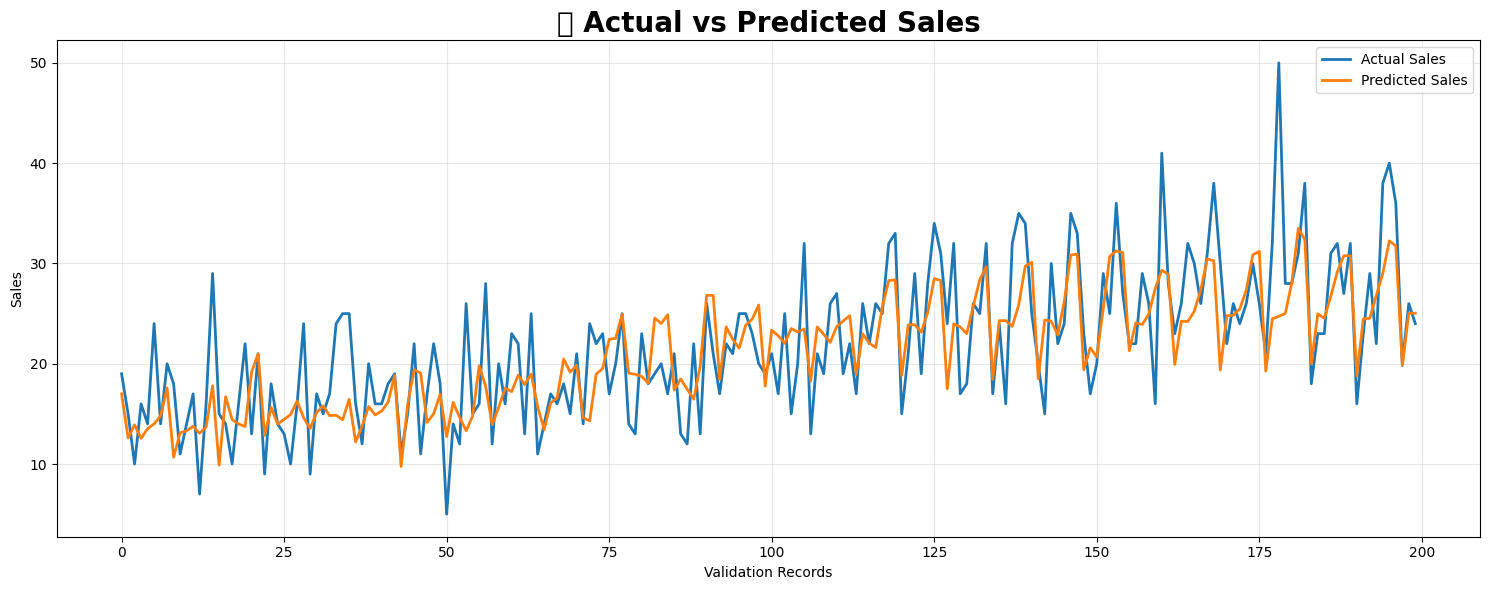

In [37]:
# 📈 Actual vs Predicted Sales

plt.figure(figsize=(15, 6))

# Show the first 200 validation observations for readability
plt.plot(
    y_validation.values[:200],
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    y_pred[:200],
    label="Predicted Sales",
    linewidth=2
)

plt.title(
    "📈 Actual vs Predicted Sales",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Validation Records")
plt.ylabel("Sales")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_928/1993346101.py:35: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


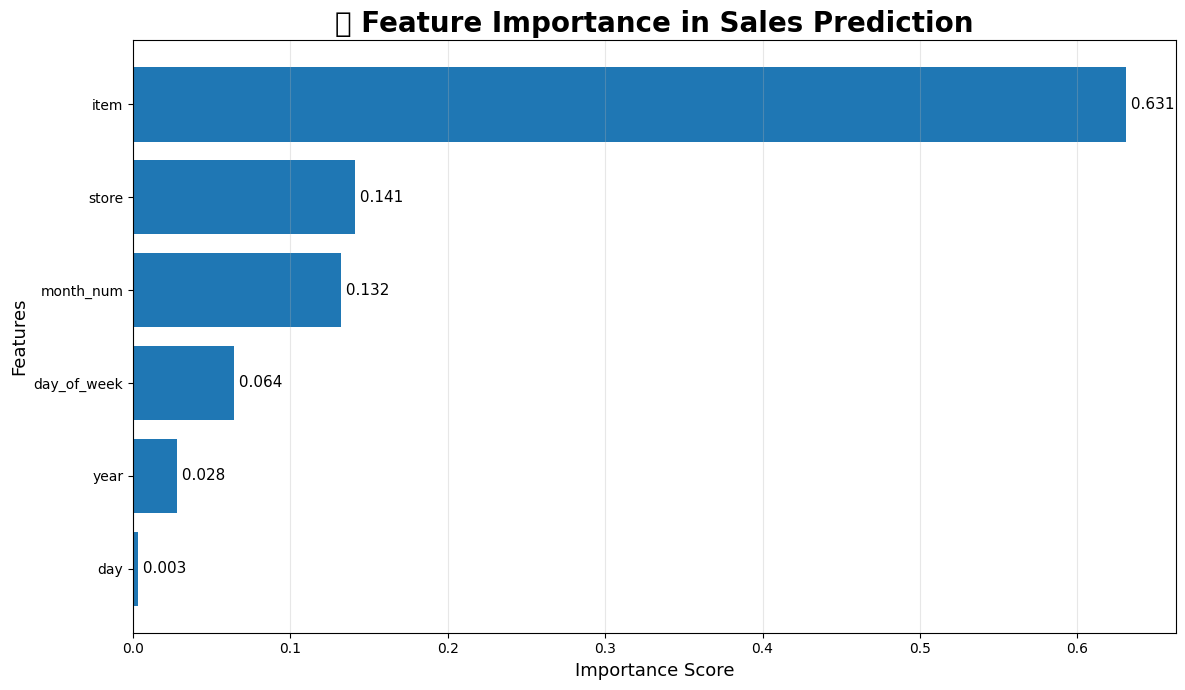

⭐ FEATURE IMPORTANCE
item           0.631032
store          0.140916
month_num      0.132304
day_of_week    0.064366
year           0.028079
day            0.003303
dtype: float64


In [38]:
# ⭐ Feature Importance

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    importance.index,
    importance.values
)

plt.title(
    "⭐ Feature Importance in Sales Prediction",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Importance Score", fontsize=13)
plt.ylabel("Features", fontsize=13)

# Show values on bars
for bar, value in zip(bars, importance.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.3f}",
        va="center",
        fontsize=11
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("⭐ FEATURE IMPORTANCE")
print(importance.sort_values(ascending=False))

In [39]:
import os

print("📂 Files in the current folder:")
print(os.listdir("."))

📂 Files in the current folder:
['.config', 'train.csv', 'sample_data']


In [40]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv


In [41]:
# 🔮 Load Test Dataset

test = pd.read_csv("test.csv")

print("✅ Test dataset loaded successfully!")
print("📊 Test data shape:", test.shape)

display(test.head())

✅ Test dataset loaded successfully!
📊 Test data shape: (45000, 4)


,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


In [42]:
# 🛠️ Feature Engineering for Test Data

test["date"] = pd.to_datetime(test["date"])

test["year"] = test["date"].dt.year
test["month_num"] = test["date"].dt.month
test["day"] = test["date"].dt.day
test["day_of_week"] = test["date"].dt.dayofweek

X_test = test[features]

print("✅ Test features created successfully!")
print("📊 Test feature shape:", X_test.shape)

display(
    test[
        ["id", "date", "year", "month_num",
         "day", "day_of_week", "store", "item"]
    ].head(10)
)

✅ Test features created successfully!
📊 Test feature shape: (45000, 6)


,id,date,year,month_num,day,day_of_week,store,item
0,0,2018-01-01,2018,1,1,0,1,1
1,1,2018-01-02,2018,1,2,1,1,1
2,2,2018-01-03,2018,1,3,2,1,1
3,3,2018-01-04,2018,1,4,3,1,1
4,4,2018-01-05,2018,1,5,4,1,1
5,5,2018-01-06,2018,1,6,5,1,1
6,6,2018-01-07,2018,1,7,6,1,1
7,7,2018-01-08,2018,1,8,0,1,1
8,8,2018-01-09,2018,1,9,1,1,1
9,9,2018-01-10,2018,1,10,2,1,1


In [43]:
# 🔮 Predict Sales for the Next 3 Months

print("🔮 Generating 3-month sales forecast...")

test_predictions = model.predict(X_test)

# Sales cannot be negative
test_predictions = np.maximum(test_predictions, 0)

print("✅ Forecast generated successfully!")

print("\n📊 First 10 Predictions:")
print(test_predictions[:10])

🔮 Generating 3-month sales forecast...
✅ Forecast generated successfully!

📊 First 10 Predictions:
[13.09246002 13.64556518 14.42688149 12.31261709 14.0017853  14.41756008
 17.14881763 10.85641742 13.12927902 13.59604652]


In [44]:
# 📄 Create Final Submission File

submission = pd.DataFrame({
    "id": test["id"],
    "sales": test_predictions
})

# Save as CSV
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv created successfully!")
print("📊 Submission shape:", submission.shape)

print("\n📋 First 10 rows:")
display(submission.head(10))

✅ submission.csv created successfully!
📊 Submission shape: (45000, 2)

📋 First 10 rows:


,id,sales
0,0,13.092460
1,1,13.645565
2,2,14.426881
3,3,12.312617
4,4,14.001785
5,5,14.417560
6,6,17.148818
7,7,10.856417
8,8,13.129279
9,9,13.596047


In [46]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>